# Handwritten Digit Recognition using K-Nearest Neighbors (KNN)
This project implements a K-Nearest Neighbors (KNN) classifier to recognize handwritten digits from the MNIST dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Data Preparation

In [2]:
df = pd.read_csv('./train.csv')
print(df.shape)

(42000, 785)


In [3]:
print(df.columns)

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='str', length=785)


In [4]:
df.head(n=5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
data = df.values
print(data.shape)
print(type(data))

(42000, 785)
<class 'numpy.ndarray'>


In [6]:
X = data[:,1:]  # all rows after 1st col.
Y = data[:,0]   # all rows but only 0th col.

print(X.shape,Y.shape)

(42000, 784) (42000,)


In [7]:
# train test split

split = int(0.8*X.shape[0])    #split entire dataset into 2 parts training(80%) & testing(20%). 
print(split)

X_train = X[:split,:]  #row till split , all col.
Y_train = Y[:split]  #all rows

X_test = X[split:,:]
Y_test = Y[split:]

print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

33600
(33600, 784) (33600,)
(8400, 784) (8400,)


## Visualizing Sample Digits

The pixel values are reshaped into 28×28 images to visualize handwritten digits.

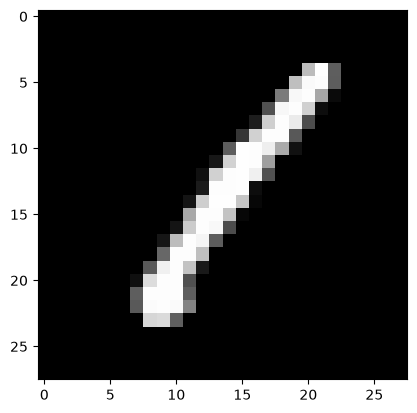

1


In [8]:
def drawImg(sample):
    img = sample.reshape((28,28))  #reshape because img we have flattened end.
    plt.imshow(img,cmap='gray')   # imshow - draw img using matplotlib or use cv2(learn latter)
    plt.show()
    
drawImg(X_train[0])     # test for any index in perticular data
print(Y_train[0])  
    
    

## Implementing K-Nearest Neighbors (KNN)

The KNN algorithm is implemented manually using Euclidean distance. For each test image, the distances to training samples are calculated and the most frequent class among the nearest neighbors is selected as the prediction.

In [9]:
#use same knn algo code

def dist(x1,x2):
    return np.sqrt(sum((x1-x2)**2))

def knn(X,Y,queryPoint,k=5):
    
    vals = []
    m = X.shape[0]
    
    for i in range(m):
        d = dist(queryPoint,X[i])
        vals.append((d,Y[i]))
        
    
    vals = sorted(vals)
    # Nearest/First K points
    vals = vals[:k]
    
    vals = np.array(vals)
    
    #print(vals)
    
    new_vals = np.unique(vals[:,1],return_counts=True)
    #print(new_vals)
    
    index = new_vals[1].argmax()
    pred = new_vals[0][index]
    
    return pred
    
    
    

## Making a Prediction

Use the trained KNN logic to predict the digit for a sample from the test dataset.

In [10]:
pred = knn(X_train,Y_train,X_test[1])

print(int(pred))

7


## Comparing Predicted and Actual Labels

The predicted digit is compared with the actual label from the test dataset.

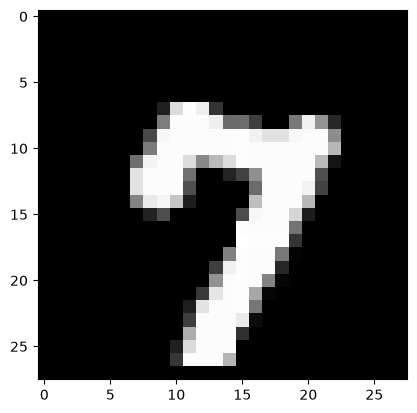

7


In [11]:

drawImg(X_test[1])
print(Y_test[1])   